# Machine Learning Examples with scikit-learn
This notebook covers a full ML workflow using the classic **Iris dataset**:
- Data exploration with pandas
- Train/test split
- Logistic Regression
- Decision Tree
- Confusion matrix heatmap
- Decision boundary visualization

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

print('All libraries loaded successfully!')

All libraries loaded successfully!


## Step 1: Load and Explore the Dataset

In [2]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print(f'Dataset shape: {df.shape}')
print(f'Classes: {list(iris.target_names)}')
print(f'\nClass distribution:')
print(df['species'].value_counts())
print()
df.head(10)

Dataset shape: (150, 5)
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


## Step 2: Preprocessing — Train / Test Split

In [3]:
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')
print(f'Features         : {X_train.shape[1]}')

Training samples : 120
Testing  samples : 30
Features         : 4


## Step 3: Model 1 — Logistic Regression

In [4]:
lr_model = LogisticRegression(max_iter=200, random_state=42)
lr_model.fit(X_train_scaled, y_train)

lr_preds = lr_model.predict(X_test_scaled)
lr_acc   = accuracy_score(y_test, lr_preds)

print(f'Logistic Regression Accuracy: {lr_acc * 100:.1f}%')
print()
print('Classification Report:')
print(classification_report(y_test, lr_preds, target_names=iris.target_names))

Logistic Regression Accuracy: 93.3%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## Step 4: Model 2 — Decision Tree

In [5]:
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

dt_preds = dt_model.predict(X_test)
dt_acc   = accuracy_score(y_test, dt_preds)

print(f'Decision Tree Accuracy: {dt_acc * 100:.1f}%')
print()
print('Classification Report:')
print(classification_report(y_test, dt_preds, target_names=iris.target_names))

Decision Tree Accuracy: 96.7%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## Step 5: Confusion Matrix — Logistic Regression vs Decision Tree

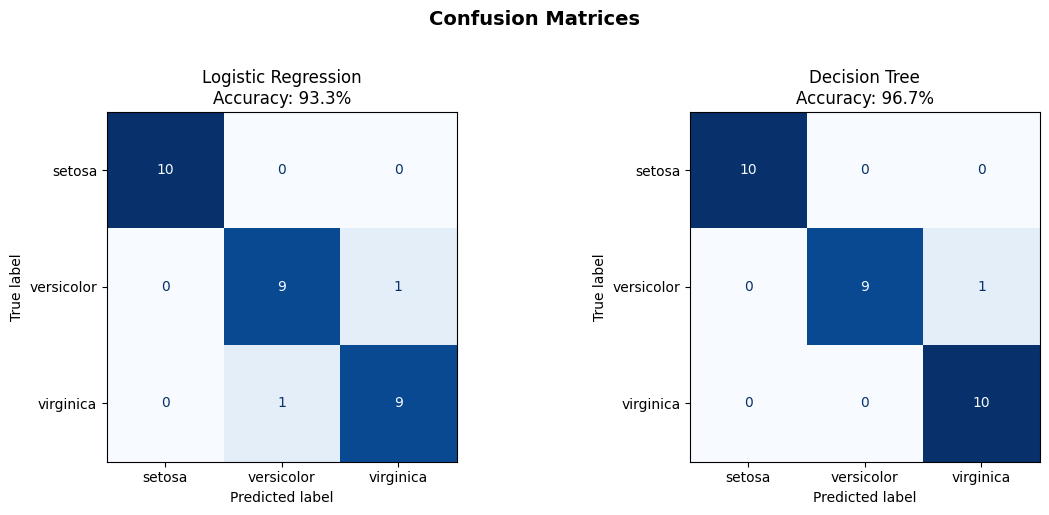

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(
    axes,
    [lr_preds, dt_preds],
    ['Logistic Regression', 'Decision Tree']
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title}\nAccuracy: {accuracy_score(y_test, preds)*100:.1f}%')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 6: Decision Boundary — 2D Visualization
Using only the first 2 features (sepal length & width) for 2D plotting.

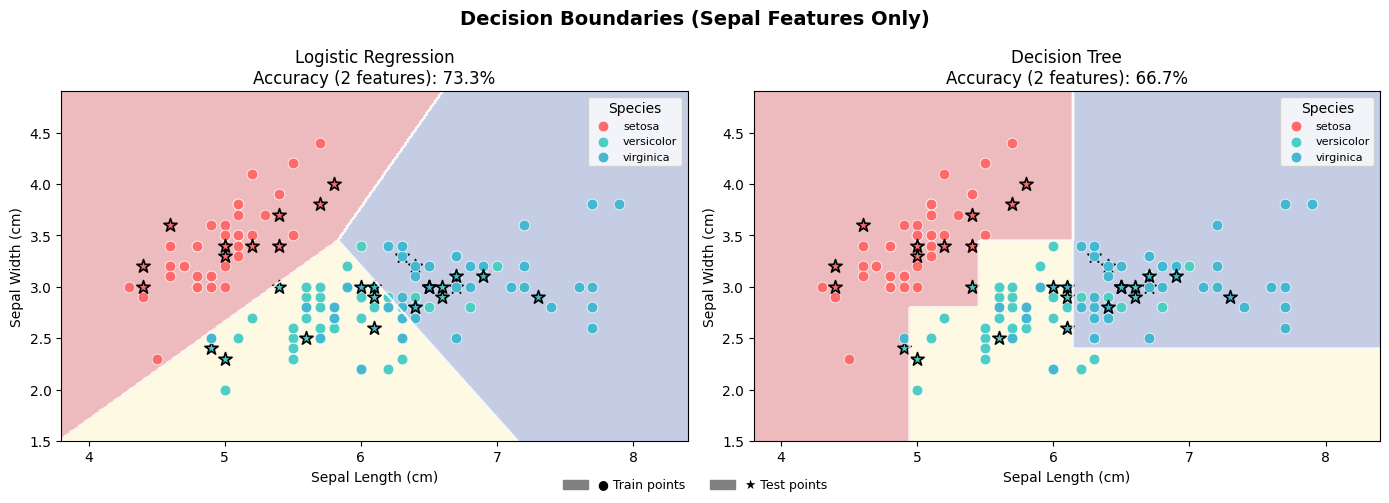

In [7]:
X_2d       = iris.data[:, :2]
X_tr, X_te, y_tr, y_te = train_test_split(X_2d, y, test_size=0.2, random_state=42, stratify=y)

models = {
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=3, random_state=42),
}

colors  = ['#FF6B6B', '#4ECDC4', '#45B7D1']
cmap    = plt.cm.RdYlBu

x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model) in zip(axes, models.items()):
    model.fit(X_tr, y_tr)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)
    ax.contour(xx, yy, Z, colors='white', linewidths=0.8, alpha=0.6)

    for cls, color in zip(np.unique(y), colors):
        mask = y_tr == cls
        ax.scatter(X_tr[mask, 0], X_tr[mask, 1],
                   color=color, edgecolors='white', linewidths=0.5,
                   s=60, label=iris.target_names[cls])
        mask_te = y_te == cls
        ax.scatter(X_te[mask_te, 0], X_te[mask_te, 1],
                   color=color, edgecolors='black', linewidths=1.2,
                   s=100, marker='*')

    acc = accuracy_score(y_te, model.predict(X_te))
    ax.set_title(f'{name}\nAccuracy (2 features): {acc*100:.1f}%')
    ax.set_xlabel('Sepal Length (cm)')
    ax.set_ylabel('Sepal Width (cm)')
    ax.legend(title='Species', fontsize=8)

circle  = mpatches.Circle((0, 0), radius=5, color='black', fill=False)
fig.legend(
    handles=[
        mpatches.Patch(color='gray', label='● Train points'),
        mpatches.Patch(color='gray', label='★ Test points'),
    ],
    loc='lower center', ncol=2, fontsize=9, frameon=False
)
plt.suptitle('Decision Boundaries (Sepal Features Only)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()